# Live Personal VAD demo

Run top to bottom. Cell **2** (enroll) is needed once per target person.
Cell **3** runs live until you press the kernel **interrupt** (stop) button.

## 1. Setup — load the frozen backbones + trained head

In [2]:
import os, sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
from src.demo.live_demo_example import StreamingDetector, run_enroll, run_mic, run_wav, DEFAULT_TARGET
from src.eval.eval_model_example import load_model
from src.features.extract_features_example import load_embedder, load_vad_model

embedder = load_embedder()
vad_model = load_vad_model()

MODEL = Path("data/models/personal_vad_noisy_trailing.pt")
if not MODEL.exists():
    MODEL = Path("data/models/personal_vad_noisy.pt")
    print(f"trailing model not found -> falling back to {MODEL} "
          f"(centered-trained: expect ~1s lag; train the trailing model!)")
model = load_model(MODEL)
print("ready")

trailing model not found -> falling back to data/models/personal_vad_noisy.pt (centered-trained: expect ~1s lag; train the trailing model!)
ready


Using cache found in /Users/ihsanbolum/.cache/torch/hub/snakers4_silero-vad_master


## 2. Enroll the target (run once — records ~20 s from the mic)

In [3]:
run_enroll(seconds=20, out_path=DEFAULT_TARGET, embedder=embedder, vad_model=vad_model)

recording...
saved /Users/ihsanbolum/Target Person Voice/data/enroll/e_target.npz  (audio kept at /Users/ihsanbolum/Target Person Voice/data/enroll/e_target.wav)


## 3. Live detection + embedding map

Runs live detection and shows a **PCA map of speaker embeddings that updates in place in
the output below** (~3×/s). The current voice (black ring) walks between the target
(green, with the gold enrollment star), each `other` speaker (its own color, from online
clustering), and `overlap` (red — which lands *between* target and an `other`, since the
mix is between two voices). A status line shows time / class / cosine / #other-speakers.

Uses `%matplotlib inline` on purpose: the mic loop blocks the kernel, so a native window
would not repaint mid-loop (you'd just see an empty starting figure). Stop with the kernel
**interrupt** button; the final map is also saved under `data/viz/`.

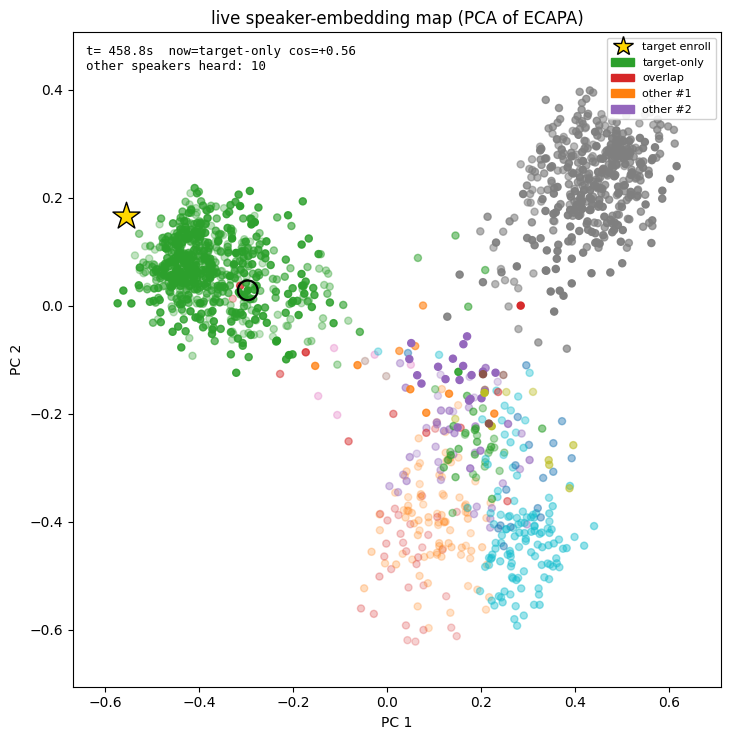

listening... speak, then have others speak; Ctrl-C (or close plot) to stop.

stopped.

other speakers heard this session: 10
saved final embedding map -> /Users/ihsanbolum/Target Person Voice/data/viz/live_embedding_map.png


In [4]:
# Live detection + live speaker-embedding map (PCA), rendered INLINE and refreshed in
# place (~3x/s) in the output below. Reuses model/embedder/vad_model from cell 1; run
# this INSTEAD of a plain-detection cell (one detector, one mic).
#
# %matplotlib inline is deliberate: the mic loop blocks the kernel, so a native window
# would not repaint mid-loop (you'd see only the empty starting figure — the bug we hit).
# Inline + an IPython display handle updates the figure in place, in every Jupyter frontend.
%matplotlib inline

from src.demo.live_viz_example import LiveEmbeddingViz, run_mic_viz

e_target = np.load(DEFAULT_TARGET)["e_target"]
detector = StreamingDetector(model, embedder, vad_model, e_target)
viz = LiveEmbeddingViz(e_target, thresh=0.2)   # lower thresh -> merges 'other' voices more

# The map updates below (status line: time / class / cos / #other-speakers). Press the
# kernel interrupt (stop) button to end — the final map also saves to data/viz/.
run_mic_viz(detector, viz)